# IMDB - result figures

Rebuilds every IMDB figure **from the saved result files**. Nothing is retrained here; this
notebook only reads, checks and plots.

The loader does not assume the results sit in one place. It searches this folder **and any
sibling folder whose name starts with `imdb`** (e.g. `imdb_sweep` / `imdb sweep`), so the
main experiments and the poison-rate sweep are picked up together even though they were run in
separate folders. `.json`, `.xlsx` and `.csv` are read interchangeably.

| Stage | Filename must contain | Provides |
|---|---|---|
| E1 | `e1` + `imdb` | clean baseline |
| E2 | `e2` + `imdb` | random-poisoned teachers |
| E3 | `e3` + `imdb` | CBS-poisoned teachers |
| E4 | `e4` + `imdb` | clean distilled student (control) |
| E5 | `e5` + `imdb` | students distilled from random teachers |
| E6 | `e6` + `imdb` | students distilled from CBS teachers |
| E7 | `e7` + `imdb` | defense table |
| Sweep | `imdb` + (`validation` or `sweep`) | poison-rate sweep (any folder) |

Figures written next to this notebook: `fig_imdb_sweep.png`, `fig_imdb_retention.png`,
`fig_imdb_defenses.png`, plus `summary_imdb.csv`.

In [1]:
!pip install pandas matplotlib openpyxl --quiet

In [2]:
"""
Flexible, multi-folder result loader.

SEARCH_ROOTS = this folder + every sibling folder whose name starts with the dataset name.
That is what lets a split layout (`imdb/results` for E1-E7, `imdb sweep/results` for the
sweep) load from a single notebook. Set SEARCH_ROOTS by hand if your layout differs.
"""
import os, re, json
import numpy as np
import pandas as pd

DATASET   = "imdb"                     # sst2 | agnews | imdb | yelp
NICE      = "IMDB"
HERE      = os.path.abspath("")               # folder holding this notebook
PARENT    = os.path.dirname(HERE)

SKIP_DIRS  = {"models", "model", "checkpoints", "venv", ".git", ".ipynb_checkpoints",
              "__pycache__", "tmp_eval", "tmp_eval2", "tmp_score", "tmp_surrogate"}
DATA_EXTS  = (".json", ".xlsx", ".xls", ".csv")

def _norm(s):
    return re.sub(r"[^a-z0-9]", "", s.lower())

def _search_roots():
    roots = [HERE]
    key = _norm(DATASET)
    for name in sorted(os.listdir(PARENT)):
        path = os.path.join(PARENT, name)
        if not os.path.isdir(path) or os.path.abspath(path) == HERE:
            continue
        if _norm(name).startswith(key):        # "imdb_sweep", "imdb sweep", ...
            roots.append(os.path.abspath(path))
    return roots

SEARCH_ROOTS = _search_roots()

def _index_files():
    out = []
    for root in SEARCH_ROOTS:
        for dirpath, dirnames, filenames in os.walk(root):
            dirnames[:] = [d for d in dirnames
                           if d.lower() not in SKIP_DIRS and not d.startswith(".")]
            for fn in filenames:
                if os.path.splitext(fn)[1].lower() in DATA_EXTS:
                    out.append(os.path.join(dirpath, fn))
    return sorted(out)

FILES = _index_files()

def _rel(path):
    # longest root first, so "<ds>_sweep" wins over the "<ds>" prefix it also starts with
    for root in sorted(SEARCH_ROOTS, key=len, reverse=True):
        if path == root or path.startswith(root + os.sep):
            return os.path.join(os.path.basename(root),
                                os.path.relpath(path, root)).replace("\\", "/")
    return path

print("search roots:")
for r in SEARCH_ROOTS:
    print("   ", r)
print("indexed", len(FILES), "candidate result files")

# ------------------------------------------------------------------ readers
def _read_any(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".json":
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    if ext in (".xlsx", ".xls"):
        book = pd.read_excel(path, sheet_name=None)
        if len(book) == 1:
            return list(book.values())[0].to_dict(orient="records")
        return {name: df.to_dict(orient="records") for name, df in book.items()}
    if ext == ".csv":
        return pd.read_csv(path).to_dict(orient="records")
    raise ValueError("unsupported result file: " + path)

def find_all(*keywords):
    hits = [p for p in FILES
            if all(k.lower() in os.path.basename(p).lower() for k in keywords)]
    # prefer files that call themselves "results", then the shortest name, then json
    hits.sort(key=lambda p: (0 if "result" in os.path.basename(p).lower() else 1,
                             len(os.path.basename(p)),
                             0 if p.lower().endswith(".json") else 1,
                             p))
    return hits

def load(*keywords, required=True):
    hits = find_all(*keywords)
    if not hits:
        if required:
            raise FileNotFoundError(
                "No result file matching {} under {}. Rename the file so its name contains "
                "those keywords, or add its folder to SEARCH_ROOTS.".format(keywords, SEARCH_ROOTS))
        print("  (missing) {} -- skipped".format(keywords))
        return None
    extra = ""
    if len(hits) > 1:
        extra = "   [also matched: {}]".format(", ".join(os.path.basename(h) for h in hits[1:]))
    print("  loaded {}{}".format(_rel(hits[0]), extra))
    return _read_any(hits[0])

# ------------------------------------------- normalisers (stages differ in shape)
def as_trigger_dict(obj):
    """Coerce an E2/E3/E5/E6 result into {'word': {...}, 'sent': {...}}."""
    if isinstance(obj, list):                       # rows from csv/xlsx
        keyed = {}
        for row in obj:
            label = str(row.get("Unnamed: 0") or row.get("index") or row.get("config") or "")
            keyed[label] = row
        obj = keyed
    if isinstance(obj, dict) and "word" in obj and "sent" in obj:
        return obj
    if isinstance(obj, dict) and "CACC" in obj and isinstance(obj["CACC"], dict):
        cols = list(obj.keys())                     # column-major: {"CACC": {"word_trigger": ...}}
        rows = list(obj[cols[0]].keys())
        out = {}
        for r in rows:
            key = "word" if "word" in str(r).lower() else "sent"
            out[key] = {c: obj[c][r] for c in cols}
        return out
    out = {}
    for k, v in obj.items():
        key = "word" if "word" in str(k).lower() else "sent"
        out[key] = v
    return out

def as_flat(obj):
    """Coerce an E1/E4 single-row result into a flat dict."""
    if isinstance(obj, list):
        return obj[0]
    if isinstance(obj, dict) and all(isinstance(v, dict) for v in obj.values()):
        inner = list(obj.values())[0]
        if set(str(k) for k in inner.keys()) <= {"0"}:   # {"CACC": {"0": 0.95}, ...}
            return {k: list(v.values())[0] for k, v in obj.items()}
        return list(obj.values())[0]                     # {"0": {"CACC": ...}}
    return obj

DEFENSES = ["No defense", "ONION", "Spectral Signature", "STRIP", "ABL"]
CONFIGS  = ["WordInsert+Random", "WordInsert+CBS", "InsertSent+Random", "InsertSent+CBS"]

def as_defense_table(obj):
    """Coerce an E7 result into {config: {defense: value}} whatever the source format."""
    if isinstance(obj, dict) and all(c in obj for c in CONFIGS):
        return obj
    if isinstance(obj, dict):                       # multi-sheet workbook
        obj = list(obj.values())[0]
    if isinstance(obj, list):                       # rows: defense name + one column per config
        out = {c: {} for c in CONFIGS}
        for row in obj:
            name = row.get("Unnamed: 0") or row.get("index") or row.get("Defense")
            for c in CONFIGS:
                if c in row:
                    out[c][str(name)] = float(row[c])
        return out
    raise ValueError("unrecognised defense-table shape")

# ------------------------------------------------------------ sweep collection
SWEEP_COLS = {"poison_rate", "ASR"}

def _sweep_tables(obj):
    """Return [(table_name, DataFrame)] for every sweep-shaped table inside a loaded object."""
    found = []
    if isinstance(obj, list) and obj and isinstance(obj[0], dict) and SWEEP_COLS <= set(obj[0]):
        found.append(("sweep", pd.DataFrame(obj)))
    elif isinstance(obj, dict):
        for key, val in obj.items():
            if "sweep" not in str(key).lower():      # skips multi_seed_raw, epoch3_check, ...
                continue
            if isinstance(val, list) and val and isinstance(val[0], dict) and SWEEP_COLS <= set(val[0]):
                found.append((str(key), pd.DataFrame(val)))
    return found

def collect_sweeps():
    """Merge every sweep table found in any search root.

    Returns (main, alt). `alt` holds runs from files whose name says "short" -- a different
    training setup (truncated documents), so it is kept out of the main curve.
    """
    main, alt = [], []
    for path in FILES:
        name = os.path.basename(path).lower()
        if DATASET not in name:
            continue
        if "validation" not in name and "sweep" not in name:
            continue
        try:
            obj = _read_any(path)
        except Exception as exc:                     # an unreadable file must not kill the notebook
            print("  ! could not read {}: {}".format(_rel(path), exc))
            continue
        for table, df in _sweep_tables(obj):
            df = df.copy()
            df["source"] = _rel(path) + ":" + table
            (alt if "short" in name else main).append(df)
            print("  sweep <- {}:{}  ({} rows)".format(_rel(path), table, len(df)))
    def _tidy(frames):
        if not frames:
            return None
        df = pd.concat(frames, ignore_index=True)
        df = df[[c for c in df.columns if not str(c).startswith("Unnamed")]]
        keys = [c for c in ("trigger", "method", "poison_rate", "seed") if c in df.columns]
        df = df.drop_duplicates(subset=keys, keep="first")
        order = [c for c in ("trigger", "method", "poison_rate") if c in df.columns]
        return df.sort_values(order).reset_index(drop=True)
    return _tidy(main), _tidy(alt)

PALETTE = {"random": "#1f77b4", "cbs": "#d62728"}
TRIGGER_NAME = {"word": "Word-insert", "sent": "InsertSent"}

search roots:
    C:\Users\Akshar\Desktop\oist papers\New folder\imdb
    C:\Users\Akshar\Desktop\oist papers\New folder\imdb_sweep
indexed 12 candidate result files


## Load every stage

In [3]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 9, "axes.titlesize": 10})

print("Loading", NICE, "results")
E1 = as_flat(load("e1", DATASET))
E2 = as_trigger_dict(load("e2", DATASET))
E3 = as_trigger_dict(load("e3", DATASET))
E4 = as_flat(load("e4", DATASET))
E5 = as_trigger_dict(load("e5", DATASET))
E6 = as_trigger_dict(load("e6", DATASET))
E7 = as_defense_table(load("e7", DATASET))

SWEEP, SWEEP_ALT = collect_sweeps()
print("\nsweep rows:", 0 if SWEEP is None else len(SWEEP),
      "| alt (short-document) rows:", 0 if SWEEP_ALT is None else len(SWEEP_ALT))
if SWEEP is not None:
    print(SWEEP.groupby(["trigger", "method"])["poison_rate"]
               .agg(n="size", lo="min", hi="max").to_string())

Loading IMDB results
  loaded imdb/results/e1_clean_imdb_results.json
  loaded imdb/results/e2_imdb_results.json
  loaded imdb/results/e3_imdb_results.json   [also matched: e3_results_imdb.json]
  loaded imdb/results/e4_results_imdb.json
  loaded imdb/results/e5_results_imdb.json
  loaded imdb/results/e6_results_imdb.json
  loaded imdb/results/e7_defense_table_imdb.json
  sweep <- imdb_sweep/results/imdb_short_validation_results.json:sweep  (28 rows)
  sweep <- imdb_sweep/results/imdb_validation_gaps.json:sweep_gaps  (12 rows)
  sweep <- imdb_sweep/results/imdb_validation_results.xlsx:sweep  (28 rows)

sweep rows: 40 | alt (short-document) rows: 28
                 n      lo   hi
trigger method                 
sent    cbs     10  0.0002  0.1
        random  10  0.0002  0.1
word    cbs     10  0.0002  0.1
        random  10  0.0002  0.1


## Sanity checks

Run these before trusting any plot. Each restates something the paper claims, so if a number
changed upstream it surfaces here rather than silently inside a figure.

In [4]:
def chk(label, ok, detail=""):
    print(("  OK   " if ok else "  FAIL ") + label + (("  " + detail) if detail else ""))
    return ok

print("Clean baseline CACC: {:.2f}%".format(E1["CACC"] * 100))
print()
print("Teachers  (ASR must sit far above its own negative control)")
for trig in ("word", "sent"):
    for tag, blk in (("Random", E2), ("CBS", E3)):
        r = blk[trig]
        chk("{:6s} {:5s} CACC={:6.2f}%  ASR={:6.2f}%  negctrl={:5.2f}%".format(
                tag, trig, r["CACC"] * 100, r["ASR"] * 100, r["ASR_negctrl"] * 100),
            r["ASR"] > r["ASR_negctrl"] * 2)

print()
print("Distilled students -- retention = student ASR / teacher ASR")
for trig in ("word", "sent"):
    rr = E5[trig]["ASR"] / E2[trig]["ASR"]
    rc = E6[trig]["ASR"] / E3[trig]["ASR"]
    print("  {:5s}  Random {:6.2f}%   CBS {:6.2f}%   CBS retains {}".format(
        trig, rr * 100, rc * 100, "more" if rc > rr else "less"))

print()
print("Clean-student control (E4): ASR = {:.2f}%  (should sit near the model's error rate)"
      .format(E4["ASR"] * 100))
print("Clean-student CACC        : {:.2f}%".format(E4["CACC"] * 100))

Clean baseline CACC: 91.97%

Teachers  (ASR must sit far above its own negative control)
  OK   Random word  CACC= 92.14%  ASR= 85.37%  negctrl= 8.08%
  OK   CBS    word  CACC= 91.56%  ASR= 79.29%  negctrl=10.82%
  OK   Random sent  CACC= 92.00%  ASR= 85.02%  negctrl= 8.32%
  OK   CBS    sent  CACC= 91.60%  ASR= 85.88%  negctrl=11.18%

Distilled students -- retention = student ASR / teacher ASR
  word   Random  10.83%   CBS  12.30%   CBS retains more
  sent   Random  10.43%   CBS  10.74%   CBS retains more

Clean-student control (E4): ASR = 9.19%  (should sit near the model's error rate)
Clean-student CACC        : 91.62%


## Figure 1 - poison-rate sweep

One panel per trigger: how attack success grows with the fraction of the training set poisoned.
Dotted lines are the negative controls (same evaluation, no trigger inserted).

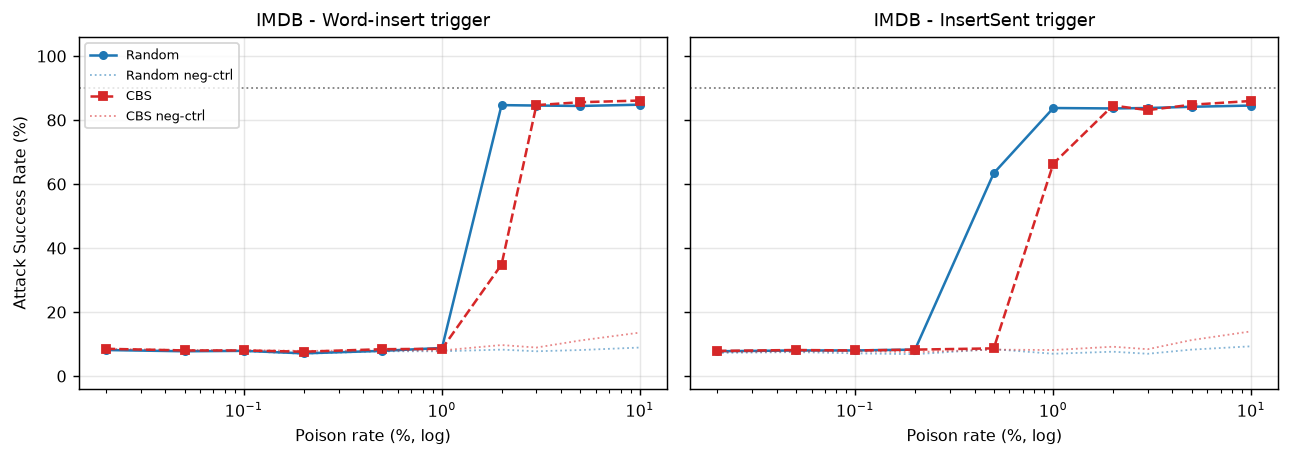


Poison budget to reach 90% ASR 
  word   Random=None  CBS=None  ->  neither reached 90% in the swept range
  sent   Random=None  CBS=None  ->  neither reached 90% in the swept range


In [5]:
def plot_sweep(df, fname, subtitle=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
    for ax, trig in zip(axes, ("word", "sent")):
        for meth in ("random", "cbs"):
            sub = df[(df.trigger == trig) & (df.method == meth)].sort_values("poison_rate")
            if len(sub) == 0:
                continue
            ax.plot(sub.poison_rate * 100, sub.ASR * 100,
                    "o-" if meth == "random" else "s--", color=PALETTE[meth], ms=4, lw=1.4,
                    label="Random" if meth == "random" else "CBS")
            if "ASR_negctrl" in sub:
                ax.plot(sub.poison_rate * 100, sub.ASR_negctrl * 100,
                        ":", color=PALETTE[meth], lw=1, alpha=0.55,
                        label=("Random neg-ctrl" if meth == "random" else "CBS neg-ctrl"))
        ax.axhline(90, color="gray", ls=":", lw=1)
        ax.set_xscale("log")
        ax.set_ylim(-4, 106)
        ax.set_xlabel("Poison rate (%, log)")
        ax.set_title("{} - {} trigger{}".format(NICE, TRIGGER_NAME[trig], subtitle))
    axes[0].set_ylabel("Attack Success Rate (%)")
    axes[0].legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

def budget_table(df, label):
    print("\nPoison budget to reach 90% ASR " + label)
    for trig in ("word", "sent"):
        got = {}
        for meth in ("random", "cbs"):
            sub = df[(df.trigger == trig) & (df.method == meth) & (df.ASR >= 0.9)]
            got[meth] = sub.poison_rate.min() if len(sub) else None
        r, c = got["random"], got["cbs"]
        if r and c:
            verdict = "CBS needs {:.1f}x the budget".format(c / r)
        elif r and not c:
            verdict = "CBS never reached 90%"
        elif c and not r:
            verdict = "Random never reached 90%"
        else:
            verdict = "neither reached 90% in the swept range"
        print("  {:5s}  Random={}  CBS={}  ->  {}".format(trig, r, c, verdict))

if SWEEP is None:
    print("no sweep file found; skipping")
else:
    plot_sweep(SWEEP, "fig_imdb_sweep.png")
    budget_table(SWEEP, "")

## Figure 1b - short-document sweep (only if that ablation exists)

IMDB was swept a second time with truncated documents. That is a different training setup, so it
gets its own panel instead of being merged into the curve above. Other datasets skip this cell.

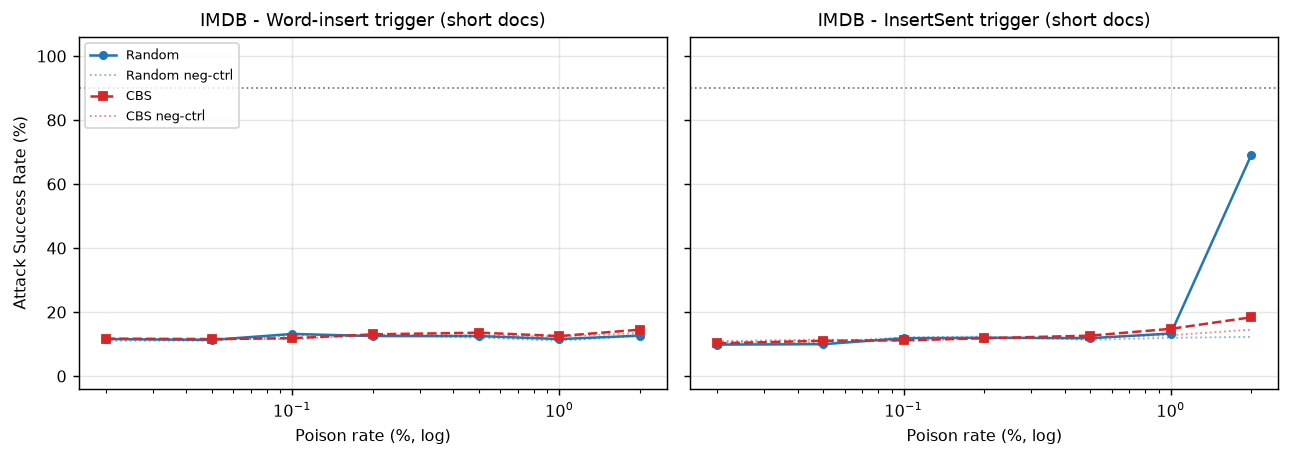


Poison budget to reach 90% ASR (short-document runs)
  word   Random=None  CBS=None  ->  neither reached 90% in the swept range
  sent   Random=None  CBS=None  ->  neither reached 90% in the swept range


In [6]:
if SWEEP_ALT is None:
    print("no short-document sweep for this dataset; skipping")
else:
    plot_sweep(SWEEP_ALT, "fig_imdb_sweep_short.png", subtitle=" (short docs)")
    budget_table(SWEEP_ALT, "(short-document runs)")

## Figure 2 - distillation retention

How much of the teacher's backdoor survives distillation on clean data.

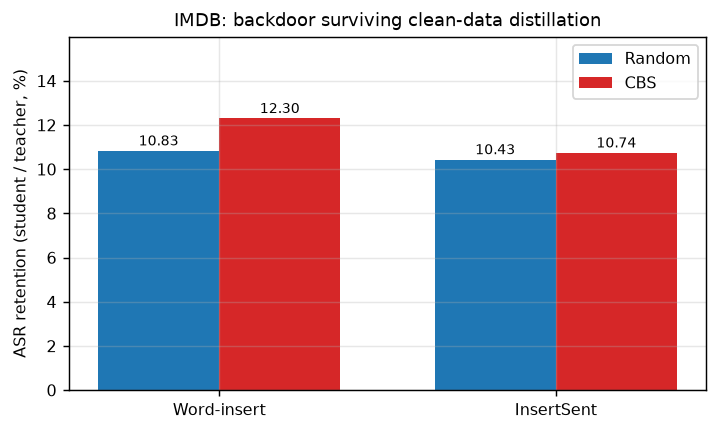

teacher -> student ASR (%)
  word   Random  85.37 ->  9.25    CBS  79.29 ->  9.75
  sent   Random  85.02 ->  8.87    CBS  85.88 ->  9.22


In [7]:
labels, rv, cv = [], [], []
for trig in ("word", "sent"):
    labels.append(TRIGGER_NAME[trig])
    rv.append(E5[trig]["ASR"] / E2[trig]["ASR"] * 100)
    cv.append(E6[trig]["ASR"] / E3[trig]["ASR"] * 100)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
x = np.arange(len(labels)); w = 0.36
b1 = ax.bar(x - w / 2, rv, w, label="Random", color=PALETTE["random"])
b2 = ax.bar(x + w / 2, cv, w, label="CBS", color=PALETTE["cbs"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("ASR retention (student / teacher, %)")
ax.set_title(NICE + ": backdoor surviving clean-data distillation")
ax.set_ylim(0, max(rv + cv) * 1.30)          # headroom so the legend clears the bar labels
ax.legend(loc="upper right")
for bars in (b1, b2):
    for bar in bars:
        ax.annotate("{:.2f}".format(bar.get_height()),
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_imdb_retention.png", dpi=200, bbox_inches="tight")
plt.show()

print("teacher -> student ASR (%)")
for trig in ("word", "sent"):
    print("  {:5s}  Random {:6.2f} -> {:5.2f}    CBS {:6.2f} -> {:5.2f}".format(
        trig, E2[trig]["ASR"] * 100, E5[trig]["ASR"] * 100,
        E3[trig]["ASR"] * 100, E6[trig]["ASR"] * 100))

## Figure 3 - defenses

ASR that remains after each defense runs its flag -> remove -> retrain loop.

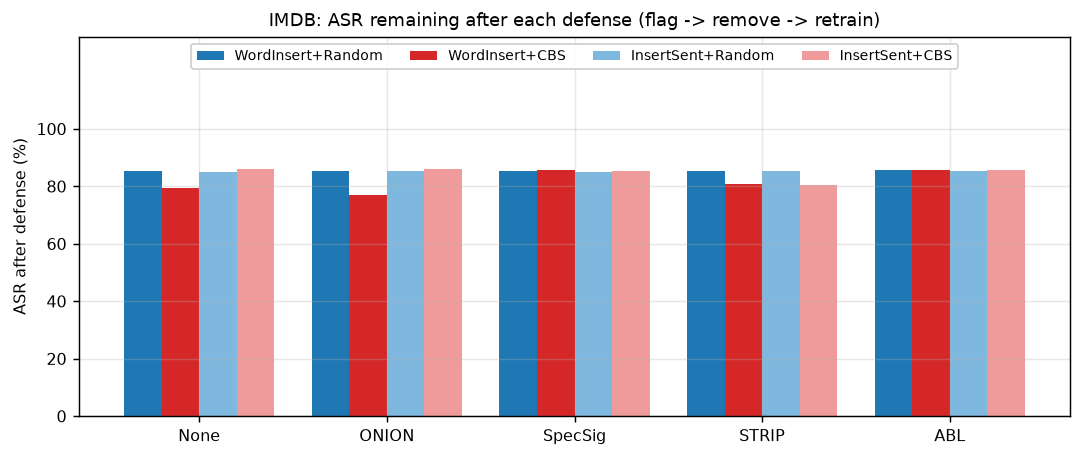

Percentage points of ASR removed, relative to each config's own baseline:
  WordInsert+Random    base= 85.4   ONION:  +0.0  Spectra:  +0.0  STRIP:  -0.1  ABL:  -0.3
  WordInsert+CBS       base= 79.3   ONION:  +2.3  Spectra:  -6.5  STRIP:  -1.5  ABL:  -6.5
  InsertSent+Random    base= 85.0   ONION:  -0.2  Spectra:  -0.1  STRIP:  -0.3  ABL:  -0.3
  InsertSent+CBS       base= 85.9   ONION:  +0.0  Spectra:  +0.5  STRIP:  +5.5  ABL:  +0.3


In [8]:
COLORS = [PALETTE["random"], PALETTE["cbs"], "#7fb8de", "#f09b9b"]

fig, ax = plt.subplots(figsize=(8.4, 3.6))
x = np.arange(len(DEFENSES)); w = 0.2
for i, (cfg, color) in enumerate(zip(CONFIGS, COLORS)):
    ax.bar(x + (i - 1.5) * w, [E7[cfg][d] for d in DEFENSES], w, color=color, label=cfg)
ax.set_xticks(x); ax.set_xticklabels(["None", "ONION", "SpecSig", "STRIP", "ABL"])
ax.set_ylabel("ASR after defense (%)")
ax.set_ylim(0, 132)                          # headroom for the legend above the bars
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_title(NICE + ": ASR remaining after each defense (flag -> remove -> retrain)")
ax.legend(fontsize=7.5, ncol=4, loc="upper center", framealpha=0.9)
plt.tight_layout()
plt.savefig("fig_imdb_defenses.png", dpi=200, bbox_inches="tight")
plt.show()

print("Percentage points of ASR removed, relative to each config's own baseline:")
for cfg in CONFIGS:
    base = E7[cfg]["No defense"]
    drops = "  ".join("{}:{:+6.1f}".format(d.split()[0][:7], base - E7[cfg][d]) for d in DEFENSES[1:])
    print("  {:20s} base={:5.1f}   {}".format(cfg, base, drops))

## Epoch control (only if that run exists)

Confirms a plateau in the sweep is not undertraining: 2 versus 3 epochs at the same poison rate.

In [9]:
ep = load(DATASET, "gaps", required=False)
if isinstance(ep, dict) and "epoch3_check" in ep:
    df = pd.DataFrame(ep["epoch3_check"])
    cols = [c for c in ["method", "trigger", "poison_rate", "epochs", "CACC", "ASR", "ASR_negctrl"]
            if c in df.columns]
    print(df[cols].to_string(index=False))
else:
    print("no epoch-control run for this dataset; skipping")

  loaded imdb_sweep/results/imdb_validation_gaps.json
method trigger  poison_rate  epochs     CACC      ASR  ASR_negctrl
random    word         0.05       3 0.931333 0.844358     0.080415
   cbs    word         0.05       3 0.915333 0.861219     0.119326
random    sent         0.05       3 0.923333 0.845655     0.090791
   cbs    sent         0.05       3 0.920000 0.852140     0.116732


## Summary table for this dataset

In [10]:
rows = [{"stage": "E1 clean baseline", "trigger": "-", "method": "-",
         "CACC": E1["CACC"], "ASR": None, "ASR_negctrl": None}]
for trig in ("word", "sent"):
    rows.append(dict(stage="E2 teacher", trigger=trig, method="random",
                     **{k: E2[trig][k] for k in ("CACC", "ASR", "ASR_negctrl")}))
    rows.append(dict(stage="E3 teacher", trigger=trig, method="cbs",
                     **{k: E3[trig][k] for k in ("CACC", "ASR", "ASR_negctrl")}))
rows.append({"stage": "E4 clean student", "trigger": "-", "method": "-",
             "CACC": E4["CACC"], "ASR": E4["ASR"], "ASR_negctrl": None})
for trig in ("word", "sent"):
    rows.append(dict(stage="E5 student", trigger=trig, method="random",
                     **{k: E5[trig][k] for k in ("CACC", "ASR", "ASR_negctrl")}))
    rows.append(dict(stage="E6 student", trigger=trig, method="cbs",
                     **{k: E6[trig][k] for k in ("CACC", "ASR", "ASR_negctrl")}))

summary = pd.DataFrame(rows)
for c in ("CACC", "ASR", "ASR_negctrl"):
    summary[c] = (summary[c].astype(float) * 100).round(2)
summary.to_csv("summary_imdb.csv", index=False)
print("saved summary_imdb.csv")
summary

saved summary_imdb.csv


,stage,trigger,method,CACC,ASR,ASR_negctrl
0,E1 clean baseline,-,-,91.97,NaN,NaN
1,E2 teacher,word,random,92.14,85.37,8.08
2,E3 teacher,word,cbs,91.56,79.29,10.82
3,E2 teacher,sent,random,92.00,85.02,8.32
4,E3 teacher,sent,cbs,91.60,85.88,11.18
5,E4 clean student,-,-,91.62,9.19,NaN
6,E5 student,word,random,91.50,9.25,9.21
7,E6 student,word,cbs,91.46,9.75,9.90
8,E5 student,sent,random,91.66,8.87,8.68
9,E6 student,sent,cbs,91.68,9.22,9.68
